In [ ]:
#Starting with the imports for all the different functions that will be used in this script and defining a defualt folder for saving plots
"""import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
from scipy.optimize import curve_fits
from astropy.timeseries import LombScargle
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from PyAstronomy.pyTiming import pyPDM
"""

'import matplotlib.pyplot as plt\nimport numpy as np\nimport pandas as pd\nimport sys\nfrom scipy.optimize import curve_fit\nfrom astropy.timeseries import LombScargle\nimport matplotlib.pyplot as plt\nfrom mpl_toolkits.axes_grid1.inset_locator import inset_axes\nfrom PyAstronomy.pyTiming import pyPDM\n'

In [2]:
#Now importing the mean and epoch photomotry, the gaia input, and the sys module to add the path to the gaiadr3_analysis folder
import os
os.chdir("C:/Users/nakia/OneDrive/Documents/GitHub/gaiadr3-analysis")
!pip install -e .
import gaiadr3_analysis.gaia_input as gi
import gaiadr3_analysis.mean_photometry as mphot
import gaiadr3_analysis.epoch_photometry as ephot

Obtaining file:///C:/Users/nakia/OneDrive/Documents/GitHub/gaiadr3-analysis
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for gaiadr3-analysis (pyproject.toml): started
  Building editable for gaiadr3-analysis (pyproject.toml): finished with status 'done'
  Created wheel for gaiadr3-analysis: filename=gaiadr3_analysis-0.1.0-0.editable-py3-none-any.whl size=11567 sha256=d0ef353d9acf5e20e0732b9f9f970ffc5e7c7feb98adff76ceed8f109574bee8
  Stored in directory: C:\Users\nakia\AppData\Local\Temp\pip-ephem-wheel-cache-qo7d1czb\wheel

In [3]:
#quering the mean photometry data for the Gaia DR3 database for the stars in the MeMis survey
#to query, input all source ids into a tuple with comma separating each source id. The tuple is then converted into a string for the proper formatting for the ADQL query.

source_ids = (
4146594906281066368, 418001477279154304, 181233674136088960,
3211026372078082048, 3220757015623151616, 3017360348171372672,
3209634905754969856, 3017364063330718080, 3017367396223983616,
3216486478101981056, 3224479171721217280, 3217413606922372992,
3326710010525962624, 2922367976673391232, 5517239366958299776,
5513811055342280448, 817013387993056640, 5338490937045044096,
5336220823491735680, 3667302325846472320, 6116497702589633152,
6005290206037557760, 6044420729667868928, 4371780385208211584,
6730764715540788352, 2032810465079954944, 2059130368252069888,
2270245431209611776, 2272185759996420992, 1796736625538995072,
3131334452194616192
)

id_list = ", ".join(str(s) for s in source_ids)

adql = f"""
SELECT source_id, designation, ra, dec, parallax,
pmra, pmdec, phot_g_mean_mag, phot_bp_mean_mag,
phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE source_id IN ({id_list})
"""

df = gi.query_by_adql(adql)
print(f"Retrieved {len(df)} stars")
df.head()

Retrieved 31 stars


,source_id,designation,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag
0,3667302325846472320,Gaia DR3 3667302325846472320,213.065666,2.409310,13.228111,-42.904556,-26.792411,4.961365,4.911909,5.030709
1,5338490937045044096,Gaia DR3 5338490937045044096,166.524167,-59.949865,2.157248,-10.210750,3.200785,6.669657,6.582181,6.798117
2,4371780385208211584,Gaia DR3 4371780385208211584,269.076645,0.670352,3.544555,-4.997440,-0.369024,5.774477,5.810996,5.652102
3,6116497702589633152,Gaia DR3 6116497702589633152,215.759187,-39.511910,8.328745,-24.420861,-20.695946,4.362966,4.268634,4.533859
4,3017360348171372672,Gaia DR3 3017360348171372672,83.790992,-5.464774,2.448864,1.618888,1.782347,8.341640,8.417046,8.116494


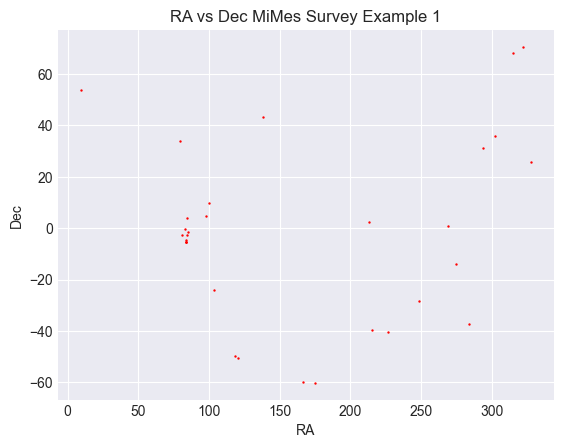

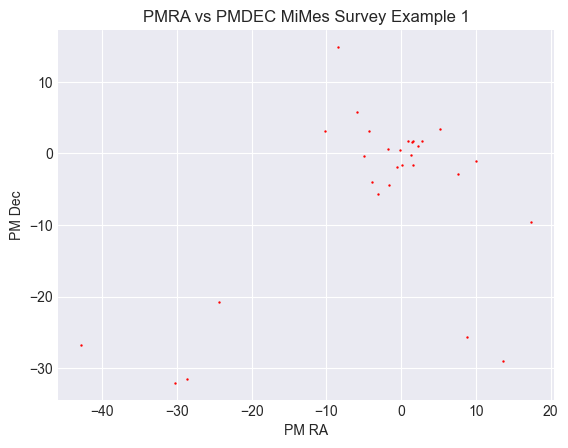

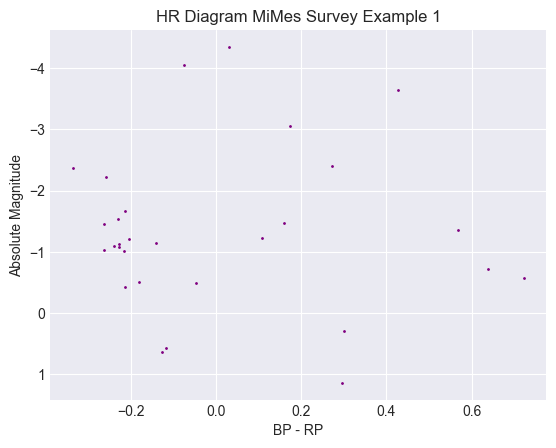

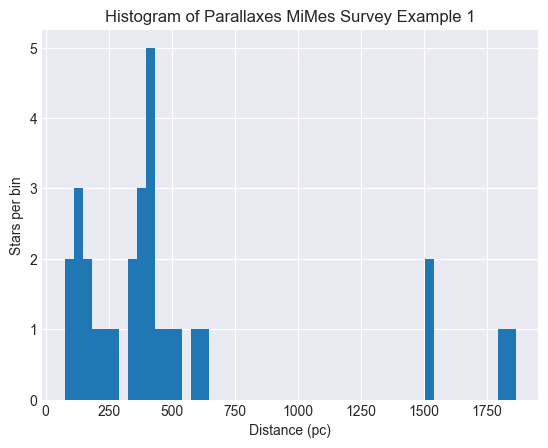

Distance, meidian: 392.72490131328766
Standard Deviation: 502.25004095572876


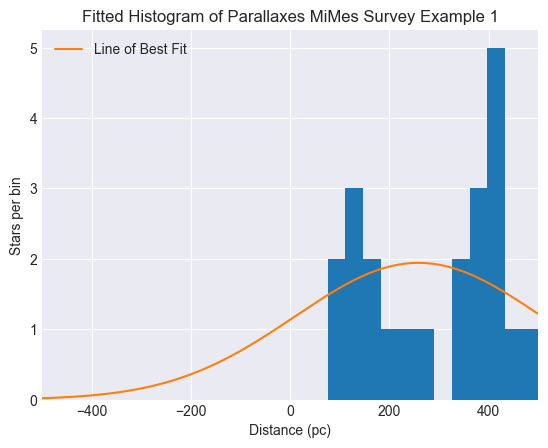

In [4]:
#Calling all functions from the MeMis survey data in the mean photometry category

#Each function is called using its respective module, mean_photometry or epoch_photometry. In this example, we have imported the mean_photometry module as mphot and the epoch_photometry module as ephot.
#The function is called using modname.function_name(parameters)

mphot.ra_vs_dec(df, title = "RA vs Dec MiMes Survey Example 1")
mphot.pmra_vs_pmdec(df, title = "PMRA vs PMDEC MiMes Survey Example 1")
mphot.plot_hr_diagram(df, title = "HR Diagram MiMes Survey Example 1")
mphot.hist(dists=df['parallax'], parallax=True, title = "Histogram of Parallaxes MiMes Survey Example 1")
mphot.fittedHist(dists=df['parallax'], parallax=True, title = "Fitted Histogram of Parallaxes MiMes Survey Example 1")

Len g, bp, and rp datasets respectively: 15, 15, 15


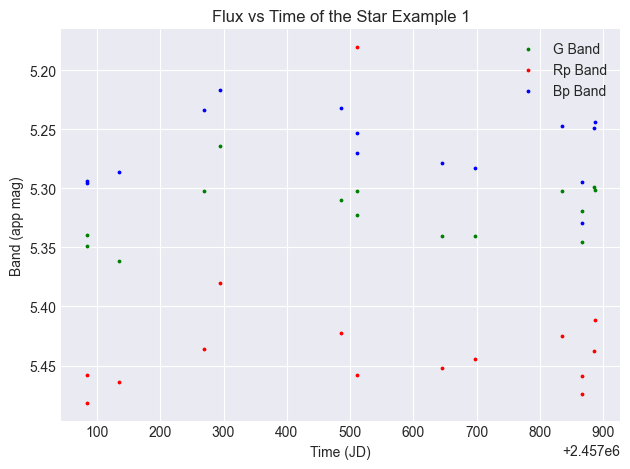

Best period: 668.246094 days (16037.906 hours)


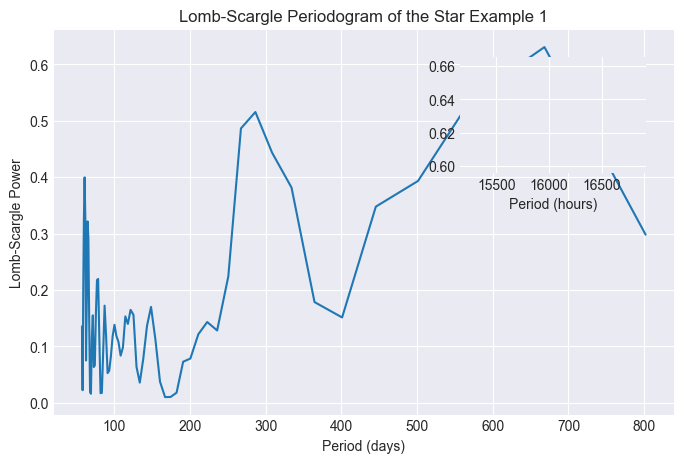

Best period = 0.1012145748987858 days


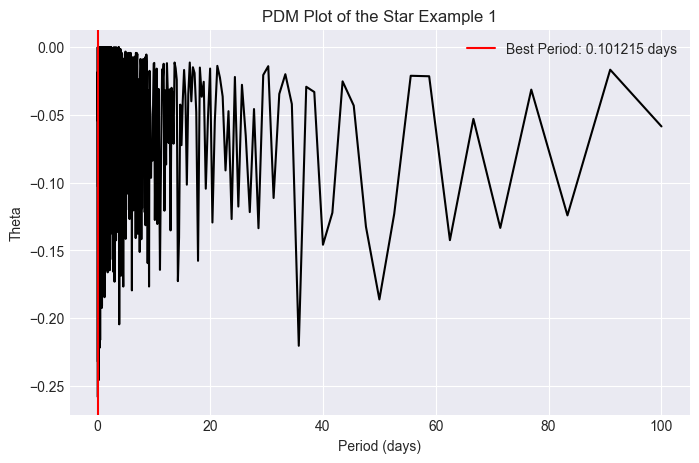

,period,frequency,theta
0,100.000000,0.010,-0.058588
1,90.909091,0.011,-0.016701
2,83.333333,0.012,-0.124276
3,76.923077,0.013,-0.031407
4,71.428571,0.014,-0.133533
...,...,...,...
9986,0.100040,9.996,-0.037568
9987,0.100030,9.997,-0.038086
9988,0.100020,9.998,-0.006582
9989,0.100010,9.999,-0.162256


In [ ]:
#Calling and saving all plots and functions from the MeMis survey data to a folder called plots in the epoch photometry category.

#Using a data link and retrieving the epoch photometry data from the star with ID 6730764715540788352 from the MeMis survey

df_datalink = gi.query_by_datalink(6730764715540788352)[6730764715540788352]

ephot.lightcurve(df_datalink, plot = True, title="Flux vs Time of the Star Example 1")
ephot.lomb_scargle(df_datalink['g_transit_time'], df_datalink['g_transit_mag'], plot = True, title="Lomb-Scargle Periodogram of the Star Example 1")
ephot.pdm(df_datalink['g_transit_time'], df_datalink['g_transit_mag'], plot = True, title="PDM Plot of the Star Example 1")